# 07. Визуализация ROC-кривых всех моделей

### 1. Загрузка данных и библиотек

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

# Загрузка валидационных данных
X_val = np.load('../data/processed/X_val_scaled.npy')
y_val = np.load('../data/processed/y_val.npy')

### 2. Загрузка обученных моделей

In [3]:
models = {}

# Логистическая регрессия
with open('../models/logistic_regression.pkl', 'rb') as f:
    models['Logistic Regression'] = pickle.load(f)

# Случайный лес
with open('../models/random_forest.pkl', 'rb') as f:
    models['Random Forest'] = pickle.load(f)

# XGBoost
with open('../models/xgboost.pkl', 'rb') as f:
    models['XGBoost'] = pickle.load(f)

# CatBoost
with open('../models/catboost.pkl', 'rb') as f:
    models['CatBoost'] = pickle.load(f)

print("Все модели загружены.")

Все модели загружены.


### 3. Построение ROC-кривых

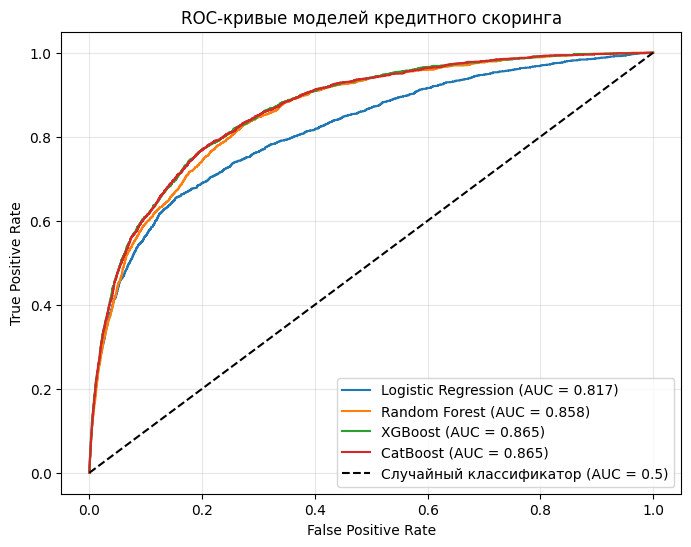

График сохранён в reports/figures/07_visualization/roc_curves_combined.png


In [4]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Опорная линия случайного классификатора
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей кредитного скоринга')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Сохранение рисунка
os.makedirs('../reports/figures/07_visualization', exist_ok=True)
plt.savefig('../reports/figures/07_visualization/roc_curves_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранён в reports/figures/07_visualization/roc_curves_combined.png")

### Сравнение зависимости F1-меры от порога классификации для всех моделей

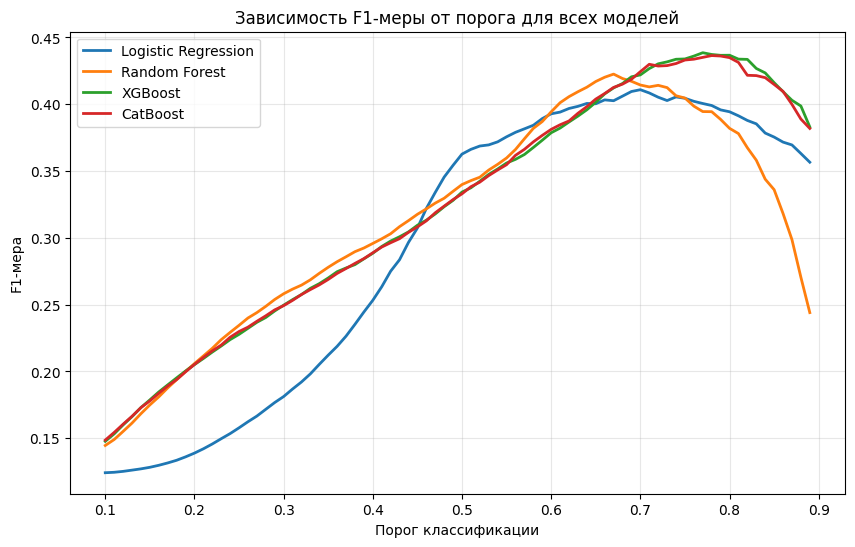

In [5]:
# Сравнение зависимости F1-меры от порога классификации для всех моделей
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_val)[:, 1]
    f1_scores = [f1_score(y_val, y_proba >= t) for t in thresholds]
    plt.plot(thresholds, f1_scores, label=name, linewidth=2)

plt.xlabel('Порог классификации')
plt.ylabel('F1-мера')
plt.title('Зависимость F1-меры от порога для всех моделей')
plt.legend()
plt.grid(alpha=0.3)
# Сохраняем в ту же папку, что и ROC-кривые
plt.savefig('../reports/figures/07_visualization/f1_vs_threshold_all_models.png', bbox_inches='tight')
plt.show()